In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

-3.7373890539654786 0.6020737851965616


C:\Users\augus\AppData\Local\Temp\ipykernel_25468\1758337725.py:65: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p2, 'k', linewidth=2, label=f'Unscented Transform Fit', color = 'red')


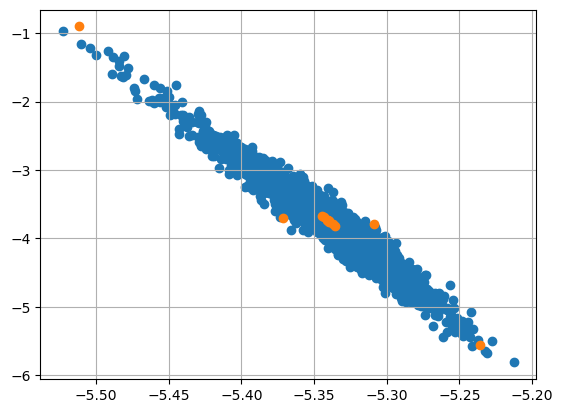

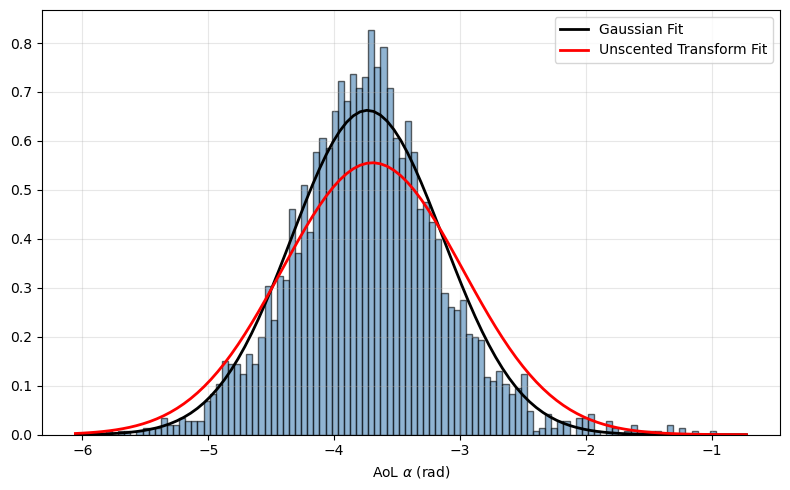

-3.7373890539654786 0.6020737851965616


C:\Users\augus\AppData\Local\Temp\ipykernel_25468\1758337725.py:91: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "k" (-> color=(0.0, 0.0, 0.0, 1)). The keyword argument will take precedence.
  plt.plot(x, p2, 'k', linewidth=2, label=f'Unscented Transform Fit', color = 'red')


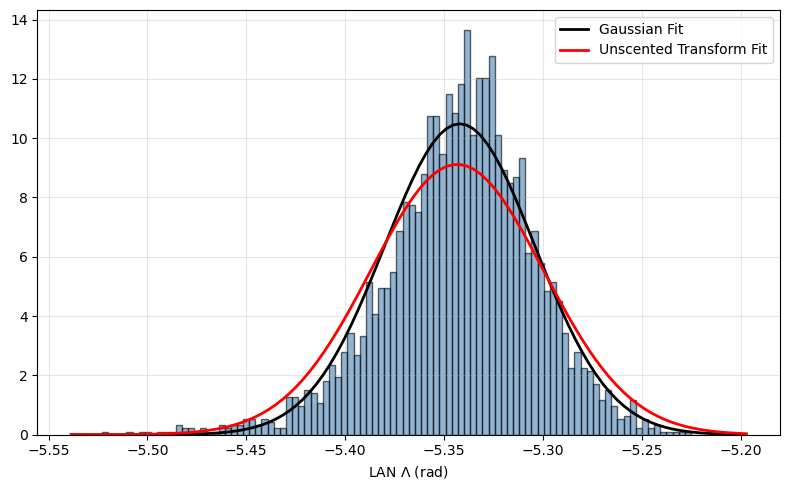

In [ ]:
df = pd.read_csv('AoLandLAN/AOLrp140ra270.csv', header=0)
AoL = pd.to_numeric(df.iloc[:, 1], errors='coerce').dropna().values
df = pd.read_csv('AoLandLAN/LANrp140ra270.csv', header=0)
LAN = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().values

sortidx = np.argsort(LAN)
AoL = AoL[sortidx]
LAN = LAN[sortidx]
AOL = np.unwrap(AoL)

df = pd.read_csv('AoLandLAN/AOLrp140ra270sig.csv', header=0)
AoLsig = pd.to_numeric(df.iloc[:, 1], errors='coerce').dropna().values
df = pd.read_csv('AoLandLAN/LANrp140ra270sig.csv', header=0)
LANsig = pd.to_numeric(df.iloc[:, 0], errors='coerce').dropna().values

sortidx = np.argsort(LANsig)
AoLsig = AoLsig[sortidx]
LANsig = LANsig[sortidx]

AOLsig = np.unwrap(AoLsig)

plt.figure()
plt.scatter(LAN, AOL)
plt.scatter(LANsig, AOLsig)
plt.grid()

def final_mean_covariance(perigee, lan, sort_mask, n):
    mean_perig, mean_lan, covariance = 0, 0, np.zeros((2,2))
    original_weights = np.array([1/(2*(n*2 - 3)) for _ in range(len(perigee))])
    original_weights[0] = (n - 3)/(n*2 - 3)
    sorted_weights = original_weights[sort_mask]
    
    for i in range(len(perigee)):
        mean_perig += sorted_weights[i] * perigee[i]
        mean_lan += sorted_weights[i] * lan[i]
        
    for i in range(len(perigee)):
        covariance[0, 0] += sorted_weights[i] * (lan[i] - mean_lan)**2
        covariance[0, 1] += sorted_weights[i] * (perigee[i] - mean_perig) * (lan[i] - mean_lan)
        covariance[1, 1] += sorted_weights[i] * (perigee[i] - mean_perig)**2
        
    covariance[1, 0] = covariance[0, 1]
    return np.array([mean_lan, mean_perig]), covariance

AOLsig = np.array(AOLsig)
LANsig = np.array(LANsig)
[LAN_mean, AOL_mean], covariance = final_mean_covariance(AOLsig, LANsig, sortidx, 7)
LAN_cov = np.sqrt(covariance[0, 0])
AOL_cov = np.sqrt(covariance[1, 1])

mu, std = norm.fit(AOL)

plt.figure(figsize=(8, 5))

plt.hist(AOL, bins=100, density=True, alpha=0.6, color='steelblue', edgecolor='black')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu, std)

p2 = norm.pdf(x, AOL_mean, AOL_cov)

plt.plot(x, p, 'k', linewidth=2, label=f'Gaussian Fit')
plt.plot(x, p2, 'k', linewidth=2, label=f'Unscented Transform Fit', color = 'red')

plt.xlabel('AoL $\\alpha$ (rad)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('AoLrp150ra270_hist.png')
plt.show()


mu2, std2 = norm.fit(LAN)

plt.figure(figsize=(8, 5))
plt.hist(LAN, bins=100, density=True, alpha=0.6, color='steelblue', edgecolor='black')

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = norm.pdf(x, mu2, std2)

p2 = norm.pdf(x, LAN_mean, LAN_cov)

plt.plot(x, p, 'k', linewidth=2, label=f'Gaussian Fit')
plt.plot(x, p2, 'k', linewidth=2, label=f'Unscented Transform Fit', color = 'red')

plt.xlabel('LAN $\\Lambda$ (rad)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig('LANrp140ra270_hist.png')
plt.show()

In [ ]:
import numpy as np

def generate_covariance_ellipse(mu, cov, n_std=1.0, num_points=100):
    mu = np.asarray(mu)
    cov = np.asarray(cov)
    
    eigenvalues, eigenvectors = np.linalg.eigh(cov)
    
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0])

    semi_major = n_std * np.sqrt(eigenvalues[0])
    semi_minor = n_std * np.sqrt(eigenvalues[1])
    
    theta = np.linspace(0, 2 * np.pi, num_points)
    
    ellipse_x_prime = semi_major * np.cos(theta)
    ellipse_y_prime = semi_minor * np.sin(theta)
    
    ellipse_x = ellipse_x_prime * np.cos(angle) - ellipse_y_prime * np.sin(angle) + mu[0]
    ellipse_y = ellipse_x_prime * np.sin(angle) + ellipse_y_prime * np.cos(angle) + mu[1]
    
    return ellipse_x, ellipse_y

[-5.34203419 -3.73738905]
[[ 0.00144794 -0.02227048]
 [-0.02227048  0.36261371]]
0.03804544711536515
0.0437594894555779


C:\Users\augus\AppData\Local\Temp\ipykernel_25468\1548735942.py:126: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


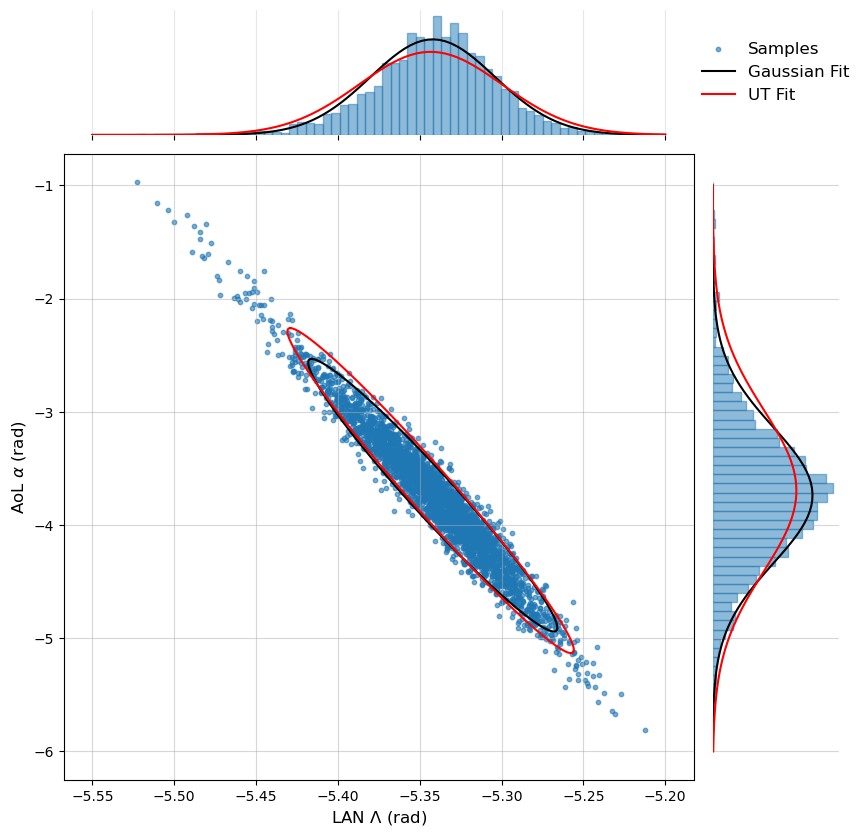

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import norm

LAN_samples = LAN
AoL_samples = AOL

mean = np.array([mu2, mu])
cov = np.cov(LAN, AOL)

print(mean)
print(cov)

LAN_sigma = LANsig
AoL_sigma = AOLsig

ellipse_gaussian_x, ellipse_gaussian_y = generate_covariance_ellipse(mean, cov, 2)
ellipse_unscented_x, ellipse_unscented_y = generate_covariance_ellipse([LAN_mean, AOL_mean], covariance, 2)

x_lan_fit = np.linspace(-5.55, -5.20, 100)
lan_gauss_fit = norm.pdf(x_lan_fit, mu2, std2)
lan_ut_fit = norm.pdf(x_lan_fit, LAN_mean, LAN_cov)

x_aol_fit = np.linspace(-6, -1, 100)
aol_gauss_fit = norm.pdf(x_aol_fit, mu, std)
aol_ut_fit = norm.pdf(x_aol_fit, AOL_mean, AOL_cov)


main_color = "tab:blue"
sigma_color = "tab:orange"

fig = plt.figure(figsize=(10, 10))

gs = gridspec.GridSpec(2, 2, width_ratios=[5, 1], height_ratios=[1, 5], wspace=0.05, hspace=0.05)

ax_main = fig.add_subplot(gs[1, 0])
ax_top = fig.add_subplot(gs[0, 0], sharex=ax_main)
ax_right = fig.add_subplot(gs[1, 1], sharey=ax_main)

ax_main.scatter(LAN_samples, AoL_samples, color=main_color, alpha=0.6, label='Samples', s=10)
#ax_main.scatter(LAN_sigma, AoL_sigma, color=sigma_color, s=50, zorder=3, label='Sigma Points', edgecolors='black') # Added black edge for clarity
ax_main.plot(ellipse_gaussian_x, ellipse_gaussian_y, color = 'black')
ax_main.plot(ellipse_unscented_x, ellipse_unscented_y, color = 'red')
ax_main.grid(True, alpha=0.5)
ax_main.set_xlabel('LAN $\Lambda$ (rad)', fontsize=12)
ax_main.set_ylabel('AoL $\\alpha$ (rad)', fontsize=12)

ax_top.hist(LAN_samples, bins=60, density=True, alpha=0.5, edgecolor=main_color, color=main_color) 
ax_top.plot(x_lan_fit, lan_gauss_fit, color='black', linewidth=1.5, linestyle='-', label='Gaussian Fit')
ax_top.plot(x_lan_fit, lan_ut_fit, color='red', linewidth=1.5, label='UT Fit')
ax_top.grid(True, alpha=0.3)
ax_right.hist(AoL_samples, bins=60, density=True, alpha=0.5, 
              edgecolor=main_color, color=main_color, orientation='horizontal')
ax_right.plot(aol_gauss_fit, x_aol_fit, color='black', linewidth=1.5)
ax_right.plot(aol_ut_fit, x_aol_fit, color='red', linewidth=1.5)

ax_right.grid(True, axis='y', alpha=0.5, linestyle='-')

ax_top.get_yaxis().set_visible(False)
ax_top.spines['left'].set_visible(False)
ax_top.spines['bottom'].set_visible(False)
ax_top.spines['top'].set_visible(False)
ax_top.spines['right'].set_visible(False)
ax_top.tick_params(axis="x", labelbottom=False)


ax_right.tick_params(axis="y", which="both", left=False, labelleft=False) 
ax_right.spines['left'].set_visible(False)

ax_right.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
ax_right.spines['bottom'].set_visible(False)
ax_right.spines['top'].set_visible(False)
ax_right.spines['right'].set_visible(False)
ax_right.spines['left'].set_visible(False)

ax_legend = fig.add_subplot(gs[0, 1])
ax_legend.axis('off')

handles_main, labels_main = ax_main.get_legend_handles_labels()

handles_top, labels_top = ax_top.get_legend_handles_labels()

all_handles = handles_main + handles_top
all_labels = labels_main + labels_top
unique_legend = dict(zip(all_labels, all_handles))

ax_legend.legend(unique_legend.values(), unique_legend.keys(), 
                 loc='center',
                 fontsize=12, 
                 frameon=False)

plt.tight_layout()
plt.show()